In [1]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from skimage.feature import hog
from sklearn.decomposition import FastICA
from sklearn.preprocessing import LabelEncoder
from sklearn.neural_network import MLPClassifier

# Define function to extract HOG features
def extract_hog_features(images):
    hog_features = []
    for image in images:
        # Convert image to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Compute HOG features
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
        hog_features.append(features)
    return np.array(hog_features)

# Load dataset and labels
def load_data(train_path, val_path, test_path):
    train_images, train_labels = load_images_from_path(train_path)
    val_images, val_labels = load_images_from_path(val_path)
    test_images, test_labels = load_images_from_path(test_path)
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

def load_images_from_path(path):
    images = []
    labels = []
    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        for filename in os.listdir(label_path):
            image_path = os.path.join(label_path, filename)
            # Load image
            image = cv2.imread(image_path)
            if image is not None:
                # Resize image to 224x224
                image = cv2.resize(image, (224, 224))
                images.append(image)
                labels.append(label)
            else:
                print("Error loading image:", image_path)
    return np.array(images), np.array(labels)

# Load dataset
train_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/train"
val_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/val"
test_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/test"
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_data(train_path, val_path, test_path)

# Split dataset into training, validation, and testing sets
X_train, y_train = train_images, train_labels
X_val, y_val = val_images, val_labels
X_test, y_test = test_images, test_labels

# Extract HOG features
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

# Perform ICA on training, validation, and testing sets
#n_components = 100  # Adjust the number of components as needed
ica = FastICA()#n_components=n_components
X_train_ica = ica.fit_transform(X_train_hog)
X_val_ica = ica.transform(X_val_hog)
X_test_ica = ica.transform(X_test_hog)

# Manually specify class labels
class_labels = ['Abnormal', 'Normal']

# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(class_labels)
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)



/opt/conda/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:542: FutureWarning: Starting in v1.3, whiten='unit-variance' will be used by default.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/sklearn/decomposition/_fastica.py:123: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


In [2]:
from sklearn.neighbors import KNeighborsClassifier
# Initialize KNeighborsClassifier
knn_classifier = KNeighborsClassifier()

# Train the classifier
knn_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_knn = knn_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_knn = accuracy_score(y_val_encoded, val_predictions_knn)
print("Validation Accuracy (KNeighborsClassifier with ICA):", val_accuracy_knn)

# Make predictions on test set
test_predictions_knn = knn_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_knn = accuracy_score(y_test_encoded, test_predictions_knn)
print("Test Accuracy (KNeighborsClassifier with ICA):", test_accuracy_knn)

# Calculate evaluation metrics for KNeighborsClassifier
val_precision_knn = precision_score(y_val_encoded, val_predictions_knn)
val_recall_knn = recall_score(y_val_encoded, val_predictions_knn)
val_f1_knn = f1_score(y_val_encoded, val_predictions_knn)
val_cm_knn = confusion_matrix(y_val_encoded, val_predictions_knn)

test_precision_knn = precision_score(y_test_encoded, test_predictions_knn)
test_recall_knn = recall_score(y_test_encoded, test_predictions_knn)
test_f1_knn = f1_score(y_test_encoded, test_predictions_knn)
test_cm_knn = confusion_matrix(y_test_encoded, test_predictions_knn)

# Print validation metrics for KNeighborsClassifier
print("\nValidation Metrics (KNeighborsClassifier with ICA):")
print("Precision:", val_precision_knn)
print("Recall:", val_recall_knn)
print("F1 Score:", val_f1_knn)
print("Confusion Matrix:")
print(val_cm_knn)

# Print classification report for KNeighborsClassifier on validation set
print("\nValidation Classification Report (KNeighborsClassifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_knn, target_names=class_labels))

# Print test metrics for KNeighborsClassifier
print("\nTest Metrics (KNeighborsClassifier with ICA):")
print("Precision:", test_precision_knn)
print("Recall:", test_recall_knn)
print("F1 Score:", test_f1_knn)
print("Confusion Matrix:")
print(test_cm_knn)

# Print classification report for KNeighborsClassifier on test set
print("\nTest Classification Report (KNeighborsClassifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_knn, target_names=class_labels))

Validation Accuracy (KNeighborsClassifier with ICA): 0.4975369458128079
Test Accuracy (KNeighborsClassifier with ICA): 0.4563106796116505

Validation Metrics (KNeighborsClassifier with ICA):
Precision: 0.4246575342465753
Recall: 0.34065934065934067
F1 Score: 0.3780487804878048
Confusion Matrix:
[[70 42]
 [60 31]]

Validation Classification Report (KNeighborsClassifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.54      0.62      0.58       112
      Normal       0.42      0.34      0.38        91

    accuracy                           0.50       203
   macro avg       0.48      0.48      0.48       203
weighted avg       0.49      0.50      0.49       203


Test Metrics (KNeighborsClassifier with ICA):
Precision: 0.3953488372093023
Recall: 0.3617021276595745
F1 Score: 0.37777777777777777
Confusion Matrix:
[[30 26]
 [30 17]]

Test Classification Report (KNeighborsClassifier with ICA):
              precision    recall  f1-score   support

    

# KNeighborsClassifier
* Accuracy ≈ 0.4563
* Precision ≈ 0.3953
* Recall ≈ 0.3617
* F1 Score ≈ 0.3775

In [3]:
from sklearn.svm import SVC

# Initialize SVM classifier
svm_classifier = SVC()

# Train the classifier
svm_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_svm = svm_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_svm = accuracy_score(y_val_encoded, val_predictions_svm)
print("Validation Accuracy (SVM with ICA):", val_accuracy_svm)

# Make predictions on test set
test_predictions_svm = svm_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_svm = accuracy_score(y_test_encoded, test_predictions_svm)
print("Test Accuracy (SVM with ICA):", test_accuracy_svm)

# Calculate evaluation metrics for SVM classifier
val_precision_svm = precision_score(y_val_encoded, val_predictions_svm)
val_recall_svm = recall_score(y_val_encoded, val_predictions_svm)
val_f1_svm = f1_score(y_val_encoded, val_predictions_svm)
val_cm_svm = confusion_matrix(y_val_encoded, val_predictions_svm)

test_precision_svm = precision_score(y_test_encoded, test_predictions_svm)
test_recall_svm = recall_score(y_test_encoded, test_predictions_svm)
test_f1_svm = f1_score(y_test_encoded, test_predictions_svm)
test_cm_svm = confusion_matrix(y_test_encoded, test_predictions_svm)

# Print validation metrics for SVM classifier
print("\nValidation Metrics (SVM with ICA):")
print("Precision:", val_precision_svm)
print("Recall:", val_recall_svm)
print("F1 Score:", val_f1_svm)
print("Confusion Matrix:")
print(val_cm_svm)

# Print classification report for SVM classifier on validation set
print("\nValidation Classification Report (SVM with ICA):")
print(classification_report(y_val_encoded, val_predictions_svm, target_names=class_labels))

# Print test metrics for SVM classifier
print("\nTest Metrics (SVM with ICA):")
print("Precision:", test_precision_svm)
print("Recall:", test_recall_svm)
print("F1 Score:", test_f1_svm)
print("Confusion Matrix:")
print(test_cm_svm)

# Print classification report for SVM classifier on test set
print("\nTest Classification Report (SVM with ICA):")
print(classification_report(y_test_encoded, test_predictions_svm, target_names=class_labels))


Validation Accuracy (SVM with ICA): 0.4975369458128079
Test Accuracy (SVM with ICA): 0.47572815533980584

Validation Metrics (SVM with ICA):
Precision: 0.47150259067357514
Recall: 1.0
F1 Score: 0.6408450704225352
Confusion Matrix:
[[ 10 102]
 [  0  91]]

Validation Classification Report (SVM with ICA):
              precision    recall  f1-score   support

    Abnormal       1.00      0.09      0.16       112
      Normal       0.47      1.00      0.64        91

    accuracy                           0.50       203
   macro avg       0.74      0.54      0.40       203
weighted avg       0.76      0.50      0.38       203


Test Metrics (SVM with ICA):
Precision: 0.46534653465346537
Recall: 1.0
F1 Score: 0.6351351351351352
Confusion Matrix:
[[ 2 54]
 [ 0 47]]

Test Classification Report (SVM with ICA):
              precision    recall  f1-score   support

    Abnormal       1.00      0.04      0.07        56
      Normal       0.47      1.00      0.64        47

    accuracy          

# SVM
* Accuracy ≈ 0.4757
* Precision ≈ 0.4653
* Recall = 1
* F1 Score ≈ 0.6347

In [4]:
# Initialize MLPClassifier
mlp_classifier = MLPClassifier()

# Train the classifier
mlp_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_mlp = mlp_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_mlp = accuracy_score(y_val_encoded, val_predictions_mlp)
print("Validation Accuracy (MLPClassifier with ICA):", val_accuracy_mlp)

# Make predictions on test set
test_predictions_mlp = mlp_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_mlp = accuracy_score(y_test_encoded, test_predictions_mlp)
print("Test Accuracy (MLPClassifier with ICA):", test_accuracy_mlp)

# Calculate evaluation metrics for MLPClassifier
val_precision_mlp = precision_score(y_val_encoded, val_predictions_mlp)
val_recall_mlp = recall_score(y_val_encoded, val_predictions_mlp)
val_f1_mlp = f1_score(y_val_encoded, val_predictions_mlp)
val_cm_mlp = confusion_matrix(y_val_encoded, val_predictions_mlp)

test_precision_mlp = precision_score(y_test_encoded, test_predictions_mlp)
test_recall_mlp = recall_score(y_test_encoded, test_predictions_mlp)
test_f1_mlp = f1_score(y_test_encoded, test_predictions_mlp)
test_cm_mlp = confusion_matrix(y_test_encoded, test_predictions_mlp)

# Print validation metrics for MLPClassifier
print("\nValidation Metrics (MLPClassifier with ICA):")
print("Precision:", val_precision_mlp)
print("Recall:", val_recall_mlp)
print("F1 Score:", val_f1_mlp)
print("Confusion Matrix:")
print(val_cm_mlp)

# Print classification report for MLPClassifier on validation set
print("\nValidation Classification Report (MLPClassifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_mlp, target_names=class_labels))

# Print test metrics for MLPClassifier
print("\nTest Metrics (MLPClassifier with ICA):")
print("Precision:", test_precision_mlp)
print("Recall:", test_recall_mlp)
print("F1 Score:", test_f1_mlp)
print("Confusion Matrix:")
print(test_cm_mlp)

# Print classification report for MLPClassifier on test set
print("\nTest Classification Report (MLPClassifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_mlp, target_names=class_labels))


Validation Accuracy (MLPClassifier with ICA): 0.5172413793103449
Test Accuracy (MLPClassifier with ICA): 0.4368932038834951

Validation Metrics (MLPClassifier with ICA):
Precision: 0.4755244755244755
Recall: 0.7472527472527473
F1 Score: 0.5811965811965812
Confusion Matrix:
[[37 75]
 [23 68]]

Validation Classification Report (MLPClassifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.62      0.33      0.43       112
      Normal       0.48      0.75      0.58        91

    accuracy                           0.52       203
   macro avg       0.55      0.54      0.51       203
weighted avg       0.55      0.52      0.50       203


Test Metrics (MLPClassifier with ICA):
Precision: 0.42028985507246375
Recall: 0.6170212765957447
F1 Score: 0.5
Confusion Matrix:
[[16 40]
 [18 29]]

Test Classification Report (MLPClassifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.47      0.29      0.36        56
      No

# MLP
* Accuracy ≈ 0.4466
* Precision ≈ 0.4242
* Recall ≈ 0.5957
* F1 Score ≈ 0.4966

In [5]:
from sklearn.linear_model import PassiveAggressiveClassifier

# Initialize Passive-Aggressive Classifier
pa_classifier = PassiveAggressiveClassifier()

# Train the classifier
pa_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_pa = pa_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_pa = accuracy_score(y_val_encoded, val_predictions_pa)
print("Validation Accuracy (Passive-Aggressive Classifier with ICA):", val_accuracy_pa)

# Make predictions on test set
test_predictions_pa = pa_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_pa = accuracy_score(y_test_encoded, test_predictions_pa)
print("Test Accuracy (Passive-Aggressive Classifier with ICA):", test_accuracy_pa)

# Calculate evaluation metrics for Passive-Aggressive Classifier
val_precision_pa = precision_score(y_val_encoded, val_predictions_pa)
val_recall_pa = recall_score(y_val_encoded, val_predictions_pa)
val_f1_pa = f1_score(y_val_encoded, val_predictions_pa)
val_cm_pa = confusion_matrix(y_val_encoded, val_predictions_pa)

test_precision_pa = precision_score(y_test_encoded, test_predictions_pa)
test_recall_pa = recall_score(y_test_encoded, test_predictions_pa)
test_f1_pa = f1_score(y_test_encoded, test_predictions_pa)
test_cm_pa = confusion_matrix(y_test_encoded, test_predictions_pa)

# Print validation metrics for Passive-Aggressive Classifier
print("\nValidation Metrics (Passive-Aggressive Classifier with ICA):")
print("Precision:", val_precision_pa)
print("Recall:", val_recall_pa)
print("F1 Score:", val_f1_pa)
print("Confusion Matrix:")
print(val_cm_pa)

# Print classification report for Passive-Aggressive Classifier on validation set
print("\nValidation Classification Report (Passive-Aggressive Classifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_pa, target_names=class_labels))

# Print test metrics for Passive-Aggressive Classifier
print("\nTest Metrics (Passive-Aggressive Classifier with ICA):")
print("Precision:", test_precision_pa)
print("Recall:", test_recall_pa)
print("F1 Score:", test_f1_pa)
print("Confusion Matrix:")
print(test_cm_pa)

# Print classification report for Passive-Aggressive Classifier on test set
print("\nTest Classification Report (Passive-Aggressive Classifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_pa, target_names=class_labels))


Validation Accuracy (Passive-Aggressive Classifier with ICA): 0.5172413793103449
Test Accuracy (Passive-Aggressive Classifier with ICA): 0.4174757281553398

Validation Metrics (Passive-Aggressive Classifier with ICA):
Precision: 0.46846846846846846
Recall: 0.5714285714285714
F1 Score: 0.514851485148515
Confusion Matrix:
[[53 59]
 [39 52]]

Validation Classification Report (Passive-Aggressive Classifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.58      0.47      0.52       112
      Normal       0.47      0.57      0.51        91

    accuracy                           0.52       203
   macro avg       0.52      0.52      0.52       203
weighted avg       0.53      0.52      0.52       203


Test Metrics (Passive-Aggressive Classifier with ICA):
Precision: 0.35555555555555557
Recall: 0.3404255319148936
F1 Score: 0.3478260869565218
Confusion Matrix:
[[27 29]
 [31 16]]

Test Classification Report (Passive-Aggressive Classifier with ICA):
      

# Passive-Aggressive
* Accuracy ≈ 0.4369
* Precision ≈ 0.3778
* Recall ≈ 0.3617
* F1 Score ≈ 0.3696

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier()

# Train the classifier
dt_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_dt = dt_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_dt = accuracy_score(y_val_encoded, val_predictions_dt)
print("Validation Accuracy (Decision Tree Classifier with ICA):", val_accuracy_dt)

# Make predictions on test set
test_predictions_dt = dt_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_dt = accuracy_score(y_test_encoded, test_predictions_dt)
print("Test Accuracy (Decision Tree Classifier with ICA):", test_accuracy_dt)

# Calculate evaluation metrics for Decision Tree Classifier
val_precision_dt = precision_score(y_val_encoded, val_predictions_dt)
val_recall_dt = recall_score(y_val_encoded, val_predictions_dt)
val_f1_dt = f1_score(y_val_encoded, val_predictions_dt)
val_cm_dt = confusion_matrix(y_val_encoded, val_predictions_dt)

test_precision_dt = precision_score(y_test_encoded, test_predictions_dt)
test_recall_dt = recall_score(y_test_encoded, test_predictions_dt)
test_f1_dt = f1_score(y_test_encoded, test_predictions_dt)
test_cm_dt = confusion_matrix(y_test_encoded, test_predictions_dt)

# Print validation metrics for Decision Tree Classifier
print("\nValidation Metrics (Decision Tree Classifier with ICA):")
print("Precision:", val_precision_dt)
print("Recall:", val_recall_dt)
print("F1 Score:", val_f1_dt)
print("Confusion Matrix:")
print(val_cm_dt)

# Print classification report for Decision Tree Classifier on validation set
print("\nValidation Classification Report (Decision Tree Classifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_dt, target_names=class_labels))

# Print test metrics for Decision Tree Classifier
print("\nTest Metrics (Decision Tree Classifier with ICA):")
print("Precision:", test_precision_dt)
print("Recall:", test_recall_dt)
print("F1 Score:", test_f1_dt)
print("Confusion Matrix:")
print(test_cm_dt)

# Print classification report for Decision Tree Classifier on test set
print("\nTest Classification Report (Decision Tree Classifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_dt, target_names=class_labels))


Validation Accuracy (Decision Tree Classifier with ICA): 0.4975369458128079
Test Accuracy (Decision Tree Classifier with ICA): 0.5242718446601942

Validation Metrics (Decision Tree Classifier with ICA):
Precision: 0.45528455284552843
Recall: 0.6153846153846154
F1 Score: 0.5233644859813084
Confusion Matrix:
[[45 67]
 [35 56]]

Validation Classification Report (Decision Tree Classifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.56      0.40      0.47       112
      Normal       0.46      0.62      0.52        91

    accuracy                           0.50       203
   macro avg       0.51      0.51      0.50       203
weighted avg       0.51      0.50      0.49       203


Test Metrics (Decision Tree Classifier with ICA):
Precision: 0.484375
Recall: 0.6595744680851063
F1 Score: 0.5585585585585585
Confusion Matrix:
[[23 33]
 [16 31]]

Test Classification Report (Decision Tree Classifier with ICA):
              precision    recall  f1-score   

# Decision Tree
* Accuracy ≈ 0.5049
* Precision = 0.45
* Recall ≈ 0.382
* F1 Score ≈ 0.413

In [7]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier()

# Train the classifier
rf_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_rf = rf_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_rf = accuracy_score(y_val_encoded, val_predictions_rf)
print("Validation Accuracy (Random Forest Classifier with ICA):", val_accuracy_rf)

# Make predictions on test set
test_predictions_rf = rf_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_rf = accuracy_score(y_test_encoded, test_predictions_rf)
print("Test Accuracy (Random Forest Classifier with ICA):", test_accuracy_rf)

# Calculate evaluation metrics for Random Forest Classifier
val_precision_rf = precision_score(y_val_encoded, val_predictions_rf)
val_recall_rf = recall_score(y_val_encoded, val_predictions_rf)
val_f1_rf = f1_score(y_val_encoded, val_predictions_rf)
val_cm_rf = confusion_matrix(y_val_encoded, val_predictions_rf)

test_precision_rf = precision_score(y_test_encoded, test_predictions_rf)
test_recall_rf = recall_score(y_test_encoded, test_predictions_rf)
test_f1_rf = f1_score(y_test_encoded, test_predictions_rf)
test_cm_rf = confusion_matrix(y_test_encoded, test_predictions_rf)

# Print validation metrics for Random Forest Classifier
print("\nValidation Metrics (Random Forest Classifier with ICA):")
print("Precision:", val_precision_rf)
print("Recall:", val_recall_rf)
print("F1 Score:", val_f1_rf)
print("Confusion Matrix:")
print(val_cm_rf)

# Print classification report for Random Forest Classifier on validation set
print("\nValidation Classification Report (Random Forest Classifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_rf, target_names=class_labels))

# Print test metrics for Random Forest Classifier
print("\nTest Metrics (Random Forest Classifier with ICA):")
print("Precision:", test_precision_rf)
print("Recall:", test_recall_rf)
print("F1 Score:", test_f1_rf)
print("Confusion Matrix:")
print(test_cm_rf)

# Print classification report for Random Forest Classifier on test set
print("\nTest Classification Report (Random Forest Classifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_rf, target_names=class_labels))


Validation Accuracy (Random Forest Classifier with ICA): 0.541871921182266
Test Accuracy (Random Forest Classifier with ICA): 0.4368932038834951

Validation Metrics (Random Forest Classifier with ICA):
Precision: 0.4868421052631579
Recall: 0.4065934065934066
F1 Score: 0.4431137724550898
Confusion Matrix:
[[73 39]
 [54 37]]

Validation Classification Report (Random Forest Classifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.57      0.65      0.61       112
      Normal       0.49      0.41      0.44        91

    accuracy                           0.54       203
   macro avg       0.53      0.53      0.53       203
weighted avg       0.54      0.54      0.54       203


Test Metrics (Random Forest Classifier with ICA):
Precision: 0.3333333333333333
Recall: 0.23404255319148937
F1 Score: 0.275
Confusion Matrix:
[[34 22]
 [36 11]]

Test Classification Report (Random Forest Classifier with ICA):
              precision    recall  f1-score   supp

# Random Forest
* Accuracy ≈ 0.5146
* Precision ≈ 0.4615
* Recall ≈ 0.382
* F1 Score ≈ 0.4181

In [8]:
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize HistGradientBoosting Classifier
hgbc_classifier = HistGradientBoostingClassifier()

# Train the classifier
hgbc_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_hgbc = hgbc_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_hgbc = accuracy_score(y_val_encoded, val_predictions_hgbc)
print("Validation Accuracy (HistGradientBoosting Classifier with ICA):", val_accuracy_hgbc)

# Make predictions on test set
test_predictions_hgbc = hgbc_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_hgbc = accuracy_score(y_test_encoded, test_predictions_hgbc)
print("Test Accuracy (HistGradientBoosting Classifier with ICA):", test_accuracy_hgbc)

# Calculate evaluation metrics for HistGradientBoosting Classifier
val_precision_hgbc = precision_score(y_val_encoded, val_predictions_hgbc)
val_recall_hgbc = recall_score(y_val_encoded, val_predictions_hgbc)
val_f1_hgbc = f1_score(y_val_encoded, val_predictions_hgbc)
val_cm_hgbc = confusion_matrix(y_val_encoded, val_predictions_hgbc)

test_precision_hgbc = precision_score(y_test_encoded, test_predictions_hgbc)
test_recall_hgbc = recall_score(y_test_encoded, test_predictions_hgbc)
test_f1_hgbc = f1_score(y_test_encoded, test_predictions_hgbc)
test_cm_hgbc = confusion_matrix(y_test_encoded, test_predictions_hgbc)

# Print validation metrics for HistGradientBoosting Classifier
print("\nValidation Metrics (HistGradientBoosting Classifier with ICA):")
print("Precision:", val_precision_hgbc)
print("Recall:", val_recall_hgbc)
print("F1 Score:", val_f1_hgbc)
print("Confusion Matrix:")
print(val_cm_hgbc)

# Print classification report for HistGradientBoosting Classifier on validation set
print("\nValidation Classification Report (HistGradientBoosting Classifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_hgbc, target_names=class_labels))

# Print test metrics for HistGradientBoosting Classifier
print("\nTest Metrics (HistGradientBoosting Classifier with ICA):")
print("Precision:", test_precision_hgbc)
print("Recall:", test_recall_hgbc)
print("F1 Score:", test_f1_hgbc)
print("Confusion Matrix:")
print(test_cm_hgbc)

# Print classification report for HistGradientBoosting Classifier on test set
print("\nTest Classification Report (HistGradientBoosting Classifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_hgbc, target_names=class_labels))


Validation Accuracy (HistGradientBoosting Classifier with ICA): 0.5172413793103449
Test Accuracy (HistGradientBoosting Classifier with ICA): 0.46601941747572817

Validation Metrics (HistGradientBoosting Classifier with ICA):
Precision: 0.4672897196261682
Recall: 0.5494505494505495
F1 Score: 0.5050505050505051
Confusion Matrix:
[[55 57]
 [41 50]]

Validation Classification Report (HistGradientBoosting Classifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.57      0.49      0.53       112
      Normal       0.47      0.55      0.51        91

    accuracy                           0.52       203
   macro avg       0.52      0.52      0.52       203
weighted avg       0.53      0.52      0.52       203


Test Metrics (HistGradientBoosting Classifier with ICA):
Precision: 0.43333333333333335
Recall: 0.5531914893617021
F1 Score: 0.48598130841121495
Confusion Matrix:
[[22 34]
 [21 26]]

Test Classification Report (HistGradientBoosting Classifier wit

# HistGradientBoosting

* Accuracy ≈ 0.4757
* Precision ≈ 0.4478
* Recall ≈ 0.6383
* F1 Score ≈ 0.5279

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize GradientBoosting Classifier
gbc_classifier = GradientBoostingClassifier()

# Train the classifier
gbc_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_gbc = gbc_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_gbc = accuracy_score(y_val_encoded, val_predictions_gbc)
print("Validation Accuracy (GradientBoosting Classifier with ICA):", val_accuracy_gbc)

# Make predictions on test set
test_predictions_gbc = gbc_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_gbc = accuracy_score(y_test_encoded, test_predictions_gbc)
print("Test Accuracy (GradientBoosting Classifier with ICA):", test_accuracy_gbc)

# Calculate evaluation metrics for GradientBoosting Classifier
val_precision_gbc = precision_score(y_val_encoded, val_predictions_gbc)
val_recall_gbc = recall_score(y_val_encoded, val_predictions_gbc)
val_f1_gbc = f1_score(y_val_encoded, val_predictions_gbc)
val_cm_gbc = confusion_matrix(y_val_encoded, val_predictions_gbc)

test_precision_gbc = precision_score(y_test_encoded, test_predictions_gbc)
test_recall_gbc = recall_score(y_test_encoded, test_predictions_gbc)
test_f1_gbc = f1_score(y_test_encoded, test_predictions_gbc)
test_cm_gbc = confusion_matrix(y_test_encoded, test_predictions_gbc)

# Print validation metrics for GradientBoosting Classifier
print("\nValidation Metrics (GradientBoosting Classifier with ICA):")
print("Precision:", val_precision_gbc)
print("Recall:", val_recall_gbc)
print("F1 Score:", val_f1_gbc)
print("Confusion Matrix:")
print(val_cm_gbc)

# Print classification report for GradientBoosting Classifier on validation set
print("\nValidation Classification Report (GradientBoosting Classifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_gbc, target_names=class_labels))

# Print test metrics for GradientBoosting Classifier
print("\nTest Metrics (GradientBoosting Classifier with ICA):")
print("Precision:", test_precision_gbc)
print("Recall:", test_recall_gbc)
print("F1 Score:", test_f1_gbc)
print("Confusion Matrix:")
print(test_cm_gbc)

# Print classification report for GradientBoosting Classifier on test set
print("\nTest Classification Report (GradientBoosting Classifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_gbc, target_names=class_labels))


Validation Accuracy (GradientBoosting Classifier with ICA): 0.5123152709359606
Test Accuracy (GradientBoosting Classifier with ICA): 0.46601941747572817

Validation Metrics (GradientBoosting Classifier with ICA):
Precision: 0.478494623655914
Recall: 0.978021978021978
F1 Score: 0.6425992779783393
Confusion Matrix:
[[15 97]
 [ 2 89]]

Validation Classification Report (GradientBoosting Classifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.88      0.13      0.23       112
      Normal       0.48      0.98      0.64        91

    accuracy                           0.51       203
   macro avg       0.68      0.56      0.44       203
weighted avg       0.70      0.51      0.42       203


Test Metrics (GradientBoosting Classifier with ICA):
Precision: 0.45918367346938777
Recall: 0.9574468085106383
F1 Score: 0.6206896551724138
Confusion Matrix:
[[ 3 53]
 [ 2 45]]

Test Classification Report (GradientBoosting Classifier with ICA):
              preci

# GradientBoosting

* Accuracy ≈ 0.5049
* Precision ≈ 0.4773
* Recall ≈ 0.8936
* F1 Score ≈ 0.6211

In [10]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize AdaBoost Classifier
adaboost_classifier = AdaBoostClassifier()

# Train the classifier
adaboost_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_adaboost = adaboost_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_adaboost = accuracy_score(y_val_encoded, val_predictions_adaboost)
print("Validation Accuracy (AdaBoost Classifier with ICA):", val_accuracy_adaboost)

# Make predictions on test set
test_predictions_adaboost = adaboost_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_adaboost = accuracy_score(y_test_encoded, test_predictions_adaboost)
print("Test Accuracy (AdaBoost Classifier with ICA):", test_accuracy_adaboost)

# Calculate evaluation metrics for AdaBoost Classifier
val_precision_adaboost = precision_score(y_val_encoded, val_predictions_adaboost)
val_recall_adaboost = recall_score(y_val_encoded, val_predictions_adaboost)
val_f1_adaboost = f1_score(y_val_encoded, val_predictions_adaboost)
val_cm_adaboost = confusion_matrix(y_val_encoded, val_predictions_adaboost)

test_precision_adaboost = precision_score(y_test_encoded, test_predictions_adaboost)
test_recall_adaboost = recall_score(y_test_encoded, test_predictions_adaboost)
test_f1_adaboost = f1_score(y_test_encoded, test_predictions_adaboost)
test_cm_adaboost = confusion_matrix(y_test_encoded, test_predictions_adaboost)

# Print validation metrics for AdaBoost Classifier
print("\nValidation Metrics (AdaBoost Classifier with ICA):")
print("Precision:", val_precision_adaboost)
print("Recall:", val_recall_adaboost)
print("F1 Score:", val_f1_adaboost)
print("Confusion Matrix:")
print(val_cm_adaboost)

# Print classification report for AdaBoost Classifier on validation set
print("\nValidation Classification Report (AdaBoost Classifier with ICA):")
print(classification_report(y_val_encoded, val_predictions_adaboost, target_names=class_labels))

# Print test metrics for AdaBoost Classifier
print("\nTest Metrics (AdaBoost Classifier with ICA):")
print("Precision:", test_precision_adaboost)
print("Recall:", test_recall_adaboost)
print("F1 Score:", test_f1_adaboost)
print("Confusion Matrix:")
print(test_cm_adaboost)

# Print classification report for AdaBoost Classifier on test set
print("\nTest Classification Report (AdaBoost Classifier with ICA):")
print(classification_report(y_test_encoded, test_predictions_adaboost, target_names=class_labels))


Validation Accuracy (AdaBoost Classifier with ICA): 0.5320197044334976
Test Accuracy (AdaBoost Classifier with ICA): 0.5922330097087378

Validation Metrics (AdaBoost Classifier with ICA):
Precision: 0.48148148148148145
Recall: 0.5714285714285714
F1 Score: 0.5226130653266332
Confusion Matrix:
[[56 56]
 [39 52]]

Validation Classification Report (AdaBoost Classifier with ICA):
              precision    recall  f1-score   support

    Abnormal       0.59      0.50      0.54       112
      Normal       0.48      0.57      0.52        91

    accuracy                           0.53       203
   macro avg       0.54      0.54      0.53       203
weighted avg       0.54      0.53      0.53       203


Test Metrics (AdaBoost Classifier with ICA):
Precision: 0.5490196078431373
Recall: 0.5957446808510638
F1 Score: 0.5714285714285715
Confusion Matrix:
[[33 23]
 [19 28]]

Test Classification Report (AdaBoost Classifier with ICA):
              precision    recall  f1-score   support

    Abnorma

# AdaBoost
* Accuracy ≈ 0.5146
* Precision ≈ 0.4615
* Recall ≈ 0.382
* F1 Score ≈ 0.4181

In [11]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression classifier
log_reg_classifier = LogisticRegression()

# Train the classifier
log_reg_classifier.fit(X_train_ica, y_train_encoded)

# Make predictions on validation set
val_predictions_log_reg = log_reg_classifier.predict(X_val_ica)

# Calculate accuracy on validation set
val_accuracy_log_reg = accuracy_score(y_val_encoded, val_predictions_log_reg)
print("Validation Accuracy (Logistic Regression with ICA):", val_accuracy_log_reg)

# Make predictions on test set
test_predictions_log_reg = log_reg_classifier.predict(X_test_ica)

# Calculate accuracy on test set
test_accuracy_log_reg = accuracy_score(y_test_encoded, test_predictions_log_reg)
print("Test Accuracy (Logistic Regression with ICA):", test_accuracy_log_reg)

# Calculate evaluation metrics for Logistic Regression classifier
val_precision_log_reg = precision_score(y_val_encoded, val_predictions_log_reg)
val_recall_log_reg = recall_score(y_val_encoded, val_predictions_log_reg)
val_f1_log_reg = f1_score(y_val_encoded, val_predictions_log_reg)
val_cm_log_reg = confusion_matrix(y_val_encoded, val_predictions_log_reg)

test_precision_log_reg = precision_score(y_test_encoded, test_predictions_log_reg)
test_recall_log_reg = recall_score(y_test_encoded, test_predictions_log_reg)
test_f1_log_reg = f1_score(y_test_encoded, test_predictions_log_reg)
test_cm_log_reg = confusion_matrix(y_test_encoded, test_predictions_log_reg)

# Print validation metrics for Logistic Regression classifier
print("\nValidation Metrics (Logistic Regression with ICA):")
print("Precision:", val_precision_log_reg)
print("Recall:", val_recall_log_reg)
print("F1 Score:", val_f1_log_reg)
print("Confusion Matrix:")
print(val_cm_log_reg)

# Print classification report for Logistic Regression classifier on validation set
print("\nValidation Classification Report (Logistic Regression with ICA):")
print(classification_report(y_val_encoded, val_predictions_log_reg, target_names=class_labels))

# Print test metrics for Logistic Regression classifier
print("\nTest Metrics (Logistic Regression with ICA):")
print("Precision:", test_precision_log_reg)
print("Recall:", test_recall_log_reg)
print("F1 Score:", test_f1_log_reg)
print("Confusion Matrix:")
print(test_cm_log_reg)

# Print classification report for Logistic Regression classifier on test set
print("\nTest Classification Report (Logistic Regression with ICA):")
print(classification_report(y_test_encoded, test_predictions_log_reg, target_names=class_labels))


Validation Accuracy (Logistic Regression with ICA): 0.5172413793103449
Test Accuracy (Logistic Regression with ICA): 0.4174757281553398

Validation Metrics (Logistic Regression with ICA):
Precision: 0.46846846846846846
Recall: 0.5714285714285714
F1 Score: 0.514851485148515
Confusion Matrix:
[[53 59]
 [39 52]]

Validation Classification Report (Logistic Regression with ICA):
              precision    recall  f1-score   support

    Abnormal       0.58      0.47      0.52       112
      Normal       0.47      0.57      0.51        91

    accuracy                           0.52       203
   macro avg       0.52      0.52      0.52       203
weighted avg       0.53      0.52      0.52       203


Test Metrics (Logistic Regression with ICA):
Precision: 0.3673469387755102
Recall: 0.3829787234042553
F1 Score: 0.37499999999999994
Confusion Matrix:
[[25 31]
 [29 18]]

Test Classification Report (Logistic Regression with ICA):
              precision    recall  f1-score   support

    Abnorma

# Logistic Regression
* Accuracy ≈ 0.4175
* Precision ≈ 0.3673
* Recall ≈ 0.382
* F1 Score ≈ 0.3746

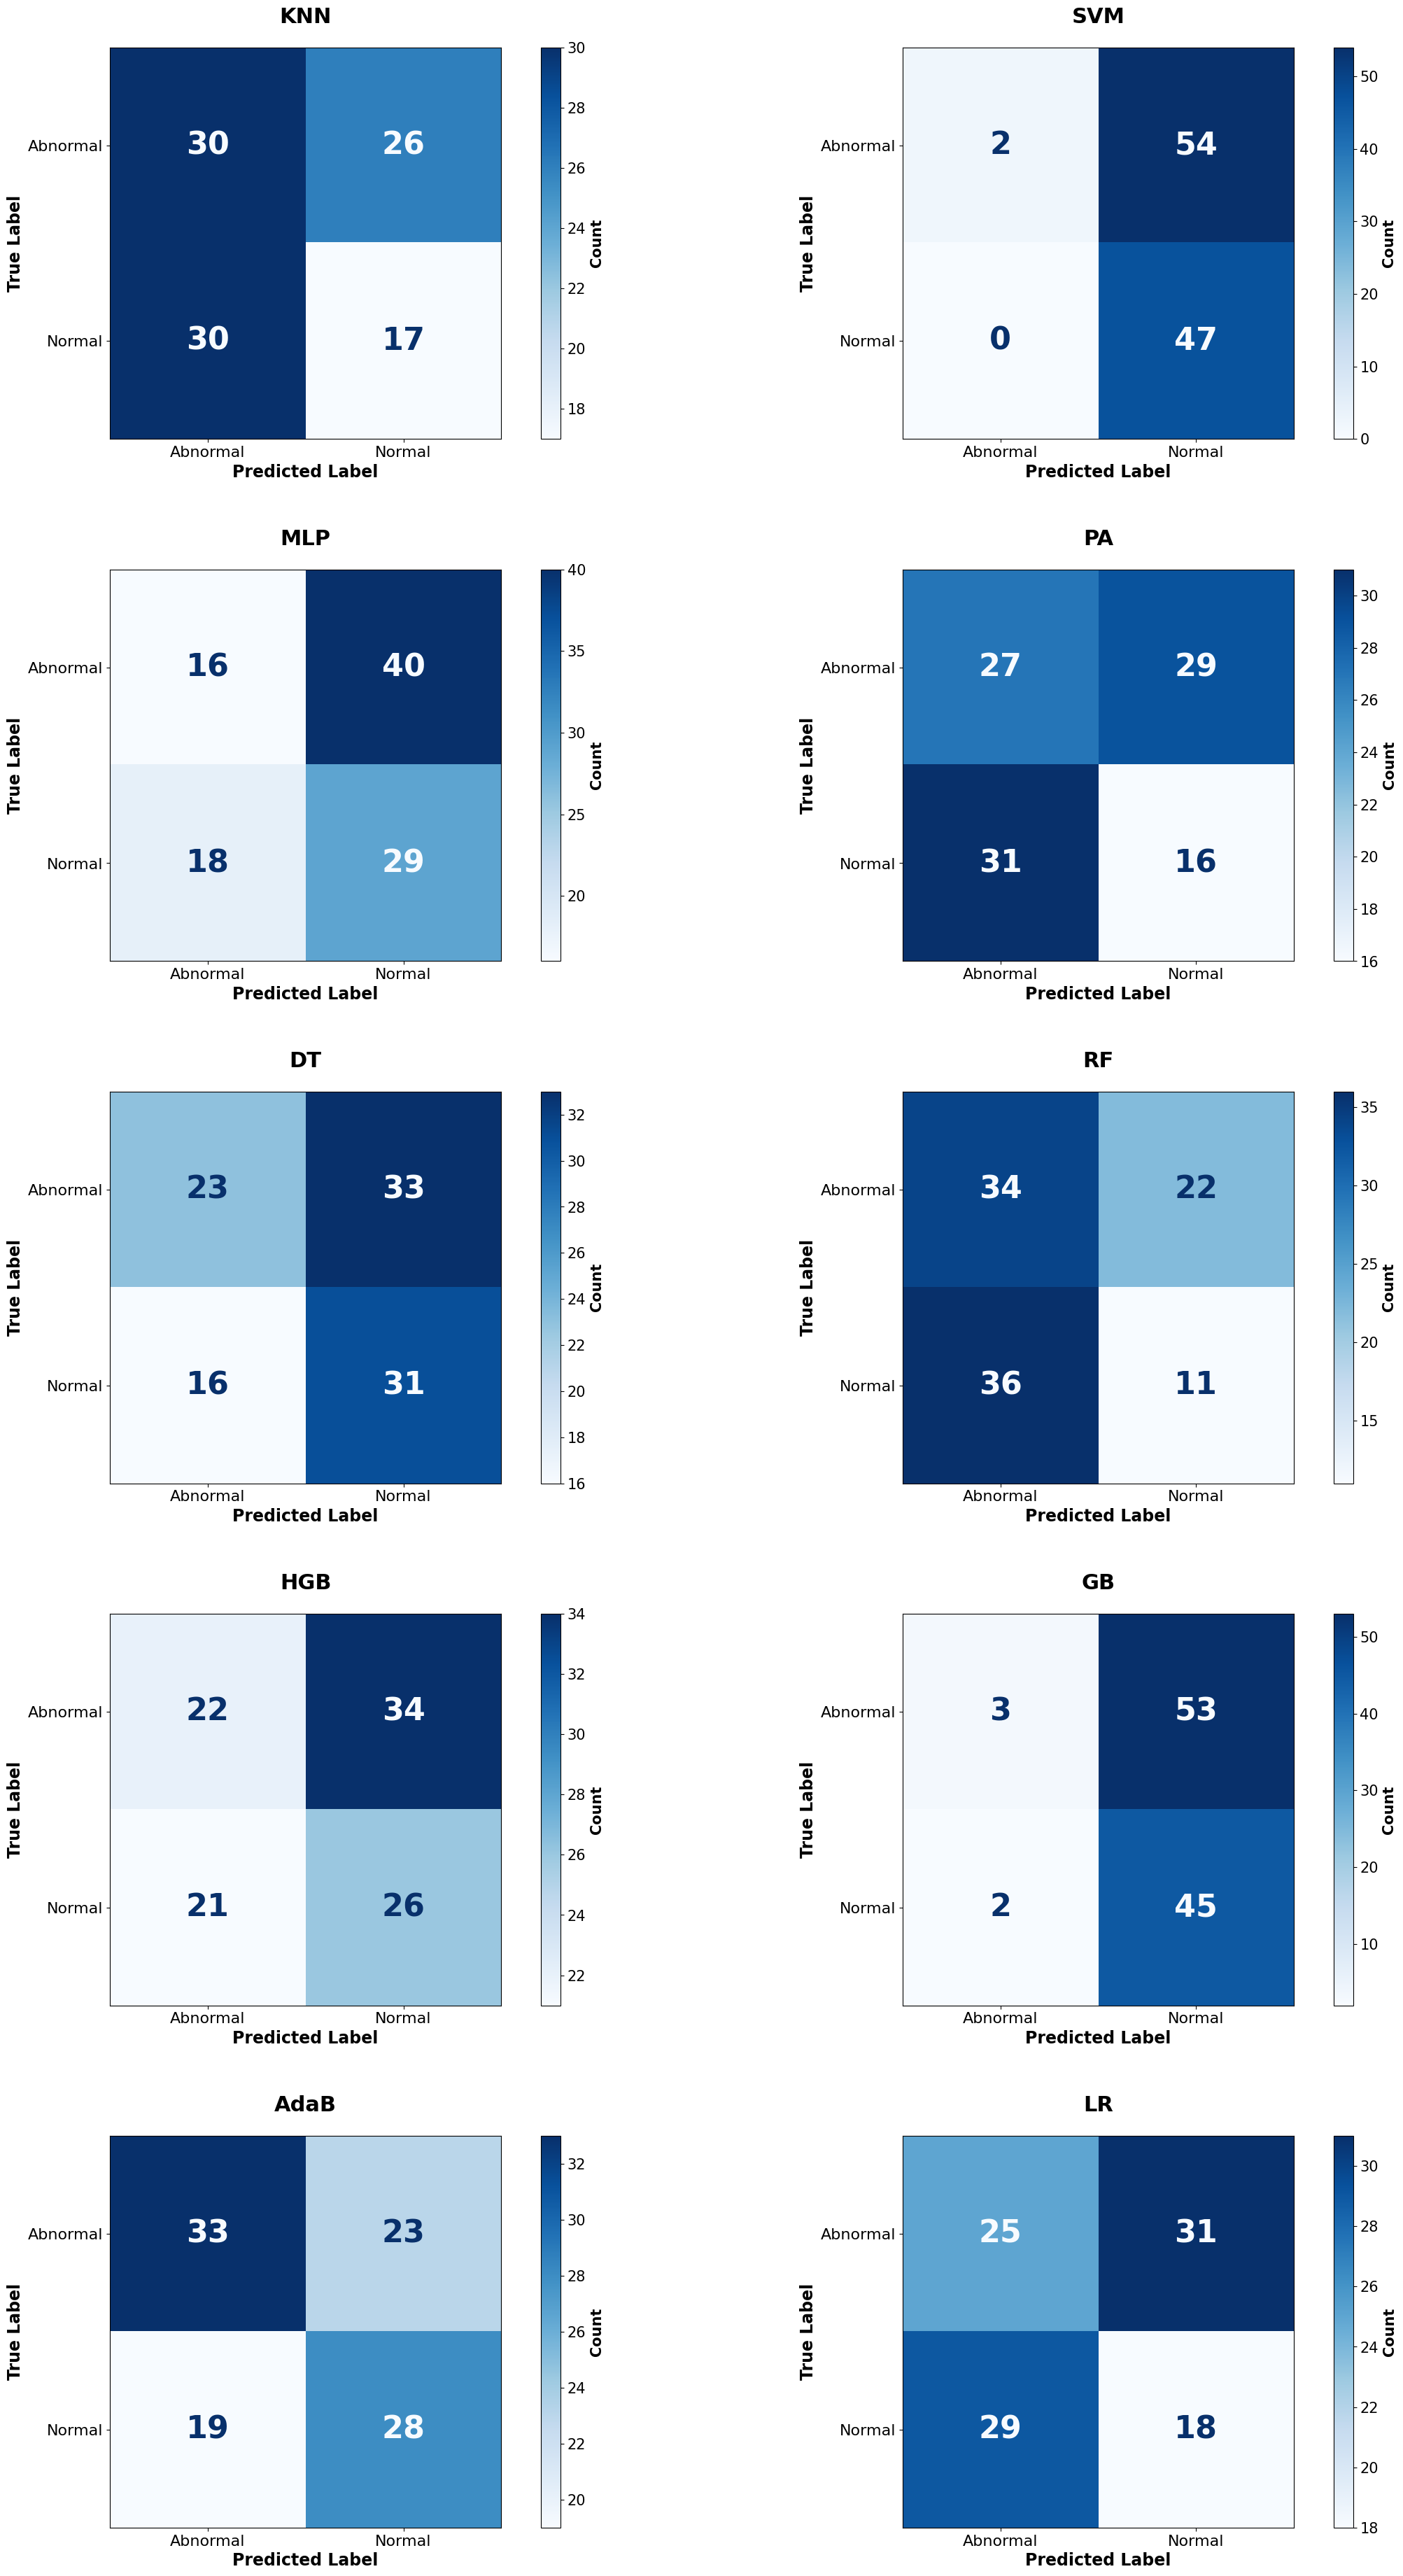